# Advanced Topics in Stochastic Programming

This notebook contains advanced topics for optimization under uncertainty.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 5 rewritten markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

## Sample average approximation

Sample average approximation (SAA) replaces an expectation with a finite sample:

\[
z_N = \min_{\mathbf{x}\in X}\frac{1}{N}\sum_{i=1}^{N}g(\mathbf{x},\boldsymbol{\xi}^i),
\qquad \boldsymbol{\xi}^i \overset{\mathrm{iid}}{\sim} P.
\]

A responsible SAA study separates:

* a **training sample** used to choose \(x_N\);
* a larger, independent **evaluation sample** used to estimate out-of-sample performance; and
* repeated samples used to measure solution variability.

One SAA solve is not a statistical guarantee. Sample size, random seed, and evaluation protocol are part of the model.
A fixed candidate must be independent of assessment data. Within an assessment batch, candidate evaluation and re-optimization may deliberately share common random numbers; the paired gap is nonnegative. Independent replications estimate its uncertainty. See Mak, Morton and Wood (1999), and Bayraksan and Morton (2006).


## Quadrature and sparse grids

Quadrature replaces an integral with a weighted sum,

\[
\int f(x)\,dx \approx \sum_{i=1}^{n}\omega_i f(x_i).
\]

Tensor-product quadrature grows exponentially with dimension. Sparse grids retain selected tensor-product points and can be effective for smooth, moderately dimensional integrands. They do not universally "defeat" dimensionality: performance depends on dimension, regularity, anisotropy, and the grid rule.

For \(y(x)=7x^3-8x^2-3x+3\) on \([-1,1]\):

* the exact integral is \(2/3\);
* the endpoint trapezoid gives \(-10\); and
* two-point Gauss--Legendre quadrature is exact because the integrand is cubic.

![Exact cubic together with the two-point trapezoidal and Gauss--Legendre interpolants.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/quadrature-gauss-vs-trapezoid.png)

In [1]:
# Install course dependencies before importing Pyomo on Colab.
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

import numpy as np

lower, upper = -1.0, 1.0


def integrand(x):
    return 7 * x**3 - 8 * x**2 - 3 * x + 3


# Odd powers integrate to zero; integrate -8*x**2 + 3 analytically.
exact = 2 / 3
trapezoid = (upper - lower) * (integrand(lower) + integrand(upper)) / 2
# Two nodes integrate polynomials through degree 3 exactly on [-1, 1].
nodes, weights = np.polynomial.legendre.leggauss(2)
gauss_legendre = sum(weights * integrand(nodes))

print(f"exact: {exact:.12f}")
print(f"trapezoid: {trapezoid:.12f}")
print(f"two-point Gauss--Legendre: {gauss_legendre:.12f}")
assert abs(gauss_legendre - exact) < 1e-12

exact: 0.666666666667
trapezoid: -10.000000000000
two-point Gauss--Legendre: 0.666666666667


### Python implementations

NumPy supplies one-dimensional Gauss--Legendre nodes through **numpy.polynomial.legendre.leggauss**. The optional [Tasmanian](https://ornl.github.io/TASMANIAN/rolling/) package provides several sparse-grid constructions.

The course does not require Tasmanian. This notebook keeps the executable calculation dependency-light and uses the repository figure below for the sparse-grid concept.

The comparison uses the same number of points in two dimensions:

* the sparse grid is a union of tensor products of nested Clenshaw--Curtis nodes; and
* the Monte Carlo sample uses a fixed random seed.

Visual coverage alone does not establish accuracy. Compare integration error on an independent test problem.

![Nested two-dimensional sparse-grid points beside the same number of seeded Monte Carlo samples.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/sparse-grid-vs-monte-carlo.png)

## A sample average approximation study

The section above is prose. This section is the computational companion: it
builds an SAA problem from sampled scenarios, watches the solution move with the
sample size, measures the optimistic bias of the sampled optimum, and computes a
multiple-replication bound on the optimality gap.

**The example is the farmer's problem**, the running example of the two
stochastic programming lectures, taken from Birge and Louveaux, *Introduction to
Stochastic Programming*, 2nd ed., §1.1a-b (pp. 4-8). The farmer allocates 500
acres among wheat, corn and sugar beets before the yield is known; purchases and
sales are the recourse, chosen after the yield is observed. The recourse is real:
a plan that looks good on average can force expensive wheat and corn purchases in
a bad year.

**One change makes it an SAA problem.** The book's Section 1.1b uses three
equally likely yield scenarios, at $-20\%$, $0$ and $+20\%$ of the mean yields. A
three-point distribution has nothing to approximate: the extensive form over all
three points *is* the true problem. So this notebook uses a continuous law,

$$\Xi \sim \mathrm{Uniform}(0.8,\ 1.2),$$

a single multiplier scaling all three crop yields. That is the book's own next
move: Section 1.1d (p. 11) takes each crop's yield uniform on
$[0.8\,\bar y_i,\ 1.2\,\bar y_i]$, chosen so the means still match Section 1.1b.

**One difference from the book, and it changes the answer.** Birge and Louveaux
make the three crop yields *independent*, which lets the recourse separate crop
by crop and even admits a closed-form $Q_i(x_i)$. This notebook instead keeps the
perfect correlation of the three-scenario model --- one common weather multiplier,
as in Section 1.1b --- so the recourse does not separate. The practical
consequence is that the expectation here is a *one-dimensional* integral, which
is why the quadrature of the previous section can compute a reference answer
below. Independent yields would make it three-dimensional, which is where the
sparse-grid discussion starts to matter.


**Cost convention.** As in the lecture, the objective is minimized *cost*.
Profit is the negative of cost, so the familiar $\$108{,}390$ appears below as a
cost of $-108{,}390$.

*Uniform yields are a modelling choice made for this demonstration, not a claim
about agriculture. Nothing below depends on the choice except the numbers.*


In [2]:
# The scenario structure is built with Pyomo Blocks: the stage 1 acreage lives on
# the model, and each sampled realization gets its own Block holding that
# sample's stage 2 purchases and sales. This is the same pattern used in
# "Stochastic Programming" (notebook 4/SP); the only difference is that the
# blocks are now indexed by a sample number instead of a named scenario, and
# there can be hundreds of them.
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent
from scipy import stats

# Pyomo's unit library has acres and metric tons but no money, so declare one.
if not hasattr(u, "USD"):
    u.load_definitions_from_strings(["USD = [currency]"])

USD_PER_ACRE = u.USD / u.acre
USD_PER_TON = u.USD / u.metric_ton
TON_PER_ACRE = u.metric_ton / u.acre

# Birge & Louveaux, 2nd ed., Table 1, p. 5: mean yields [T/acre], planting costs
# [USD/acre], purchase and selling prices [USD/T], and the cattle feed
# requirements [T]. The 6000 T quota caps sales at the favorable beet price.
CROPS = ["WHEAT", "CORN", "BEETS"]
FEED_CROPS = ["WHEAT", "CORN"]
SALE_TYPES = ["WHEAT", "CORN", "BEETS_FAVORABLE", "BEETS_UNFAVORABLE"]

MEAN_YIELD = {"WHEAT": 2.5, "CORN": 3.0, "BEETS": 20.0}
PLANT_COST = {"WHEAT": 150.0, "CORN": 230.0, "BEETS": 260.0}
BUY_PRICE = {"WHEAT": 238.0, "CORN": 210.0}
SELL_PRICE = {
    "WHEAT": 170.0,
    "CORN": 150.0,
    "BEETS_FAVORABLE": 36.0,
    "BEETS_UNFAVORABLE": 10.0,
}
FEED_NEED = {"WHEAT": 200.0, "CORN": 240.0}
TOTAL_LAND = 500.0
BEET_QUOTA = 6000.0


def build_saa_model(multipliers, weights=None, check_units=False):
    """Extensive form over a list of yield multipliers, one Block per sample.

    Arguments:
        multipliers: yield multipliers, one per sample. Each scales all three
            mean yields.
        weights: probability weight of each sample. Defaults to 1/N, which is
            the sample average approximation. Passing quadrature weights
            instead turns the same builder into a deterministic integration
            rule, which is how the reference answer below is computed.
        check_units: run assert_units_consistent. Left off by default because
            it walks every constraint on every block, and these models are
            built hundreds of times; it is exercised on a small model below.

    Return:
        A Pyomo model whose objective is the weighted average cost in USD.
    """
    multipliers = np.asarray(multipliers, dtype=float)
    n = len(multipliers)
    if weights is None:
        weights = np.full(n, 1.0 / n)
    weights = np.asarray(weights, dtype=float)
    assert len(weights) == n, "one weight per sample"

    m = pyo.ConcreteModel()
    m.CROPS = pyo.Set(initialize=CROPS)
    m.FEED_CROPS = pyo.Set(initialize=FEED_CROPS)
    m.SALE_TYPES = pyo.Set(initialize=SALE_TYPES)
    m.SAMPLES = pyo.Set(initialize=range(n))

    # Stage 1: acres of each crop, chosen before any yield is observed [acre]
    m.acreage = pyo.Var(m.CROPS, domain=pyo.NonNegativeReals, units=u.acre)

    # Stage 1 cost [USD]
    m.planting_cost = sum(PLANT_COST[c] * USD_PER_ACRE * m.acreage[c] for c in CROPS)

    # Stage 1 constraint: the farm is 500 acres [acre]
    m.total_land_constraint = pyo.Constraint(
        expr=pyo.summation(m.acreage) <= TOTAL_LAND * u.acre
    )

    def scenario_block_rule(b, i):
        """Stage 2 for sample i. `b` is the block; `m` comes from the closure."""
        # Stage 2 decisions, made after the yield is observed [T]
        b.purchases = pyo.Var(
            m.FEED_CROPS, domain=pyo.NonNegativeReals, units=u.metric_ton
        )
        b.sales = pyo.Var(m.SALE_TYPES, domain=pyo.NonNegativeReals, units=u.metric_ton)

        b.purchase_cost = sum(
            BUY_PRICE[c] * USD_PER_TON * b.purchases[c] for c in FEED_CROPS
        )
        b.sales_revenue = sum(
            SELL_PRICE[s] * USD_PER_TON * b.sales[s] for s in SALE_TYPES
        )

        # Yields realized in this sample [T/acre]
        y = {c: MEAN_YIELD[c] * multipliers[i] for c in CROPS}

        # Feed requirements: grow it, buy it, or do not sell it [T]
        b.wheat_constraint = pyo.Constraint(
            expr=y["WHEAT"] * TON_PER_ACRE * m.acreage["WHEAT"]
            + b.purchases["WHEAT"]
            - b.sales["WHEAT"]
            >= FEED_NEED["WHEAT"] * u.metric_ton
        )
        b.corn_constraint = pyo.Constraint(
            expr=y["CORN"] * TON_PER_ACRE * m.acreage["CORN"]
            + b.purchases["CORN"]
            - b.sales["CORN"]
            >= FEED_NEED["CORN"] * u.metric_ton
        )
        # Beet sales cannot exceed beet production [T]
        b.beets_constraint = pyo.Constraint(
            expr=y["BEETS"] * TON_PER_ACRE * m.acreage["BEETS"]
            - b.sales["BEETS_FAVORABLE"]
            - b.sales["BEETS_UNFAVORABLE"]
            >= 0 * u.metric_ton
        )
        b.sales["BEETS_FAVORABLE"].setub(BEET_QUOTA)

    # One Block per sample: identical structure, different yield data
    m.scenarios = pyo.Block(m.SAMPLES, rule=scenario_block_rule)

    # Weighted average cost [USD]
    m.objective = pyo.Objective(
        expr=m.planting_cost
        + sum(
            weights[i] * (m.scenarios[i].purchase_cost - m.scenarios[i].sales_revenue)
            for i in range(n)
        ),
        sense=pyo.minimize,
    )

    if check_units:
        assert_units_consistent(m)
    return m


solver = pyo.SolverFactory("appsi_highs")
assert solver.available(), "HiGHS is required for this section"
print("HiGHS version:", solver.version())


def solve_model(m):
    """Solve and return the objective value, refusing anything but optimal."""
    results = solver.solve(m)
    assert pyo.check_optimal_termination(
        results
    ), f"Solve failed: termination={results.termination_condition}"
    return pyo.value(m.objective)


def first_stage(m):
    """The stage 1 acreage as a plain array, in the order of CROPS."""
    return np.array([pyo.value(m.acreage[c]) for c in CROPS])


def saa_optimum(multipliers, weights=None):
    """Solve the sampled problem: returns (objective, acreage)."""
    m = build_saa_model(multipliers, weights)
    return solve_model(m), first_stage(m)


def evaluate_candidate(acreage, multipliers, weights=None):
    """Weighted average cost of a FIXED stage 1 plan, recourse still optimized.

    Fixing the stage 1 variables on the same model is all that separates
    "choose a plan" from "grade a plan". Every block still solves its own
    recourse problem.
    """
    m = build_saa_model(multipliers, weights)
    for c, acres in zip(CROPS, acreage):
        m.acreage[c].fix(acres)
    return solve_model(m)

HiGHS version: (1, 15, 1)


### Check the builder against the book before trusting it

Passing the three multipliers $0.8$, $1.0$, $1.2$ with equal weights rebuilds
exactly the book's three-scenario extensive form, so its answer is known:
Birge and Louveaux, Table 5, p. 8, report 170 acres of wheat, 80 of corn and 250
of sugar beets, for an expected profit of $\$108{,}390$. Lecture 10 quotes the
same number as $RP$.


In [3]:
# Birge & Louveaux Table 5, p. 8 -- the RP solution quoted in Lecture 10.
book_cost, book_acres = saa_optimum([0.8, 1.0, 1.2])
print(f"expected profit = ${-book_cost:,.0f}   (book: $108,390)")
print(
    "acres  wheat {:.1f}  corn {:.1f}  beets {:.1f}   (book: 170, 80, 250)".format(
        *book_acres
    )
)
assert abs(-book_cost - 108390.0) < 1.0
assert np.allclose(book_acres, [170.0, 80.0, 250.0], atol=1e-6)

# Exercise the unit declarations once, on a small model.
assert_units_consistent(build_saa_model([0.8, 1.0, 1.2], check_units=True))
print("units consistent")

expected profit = $108,390   (book: $108,390)
acres  wheat 170.0  corn 80.0  beets 250.0   (book: 170, 80, 250)
units consistent


### A reference answer, from the quadrature above

The uncertainty here is one-dimensional, so the true problem
$z^{*}=\min_{\mathbf{x}\in X} \mathbb{E}[f(\mathbf{x},\Xi)]$ can be solved to high
accuracy by *deterministic integration* rather than sampling: use a dense grid of
multipliers with trapezoid weights in place of the $1/N$ sampling weights. The
same `build_saa_model` does both; only the weights change.

This is a luxury, and it is the reason this notebook can check its own
statistics. Real applications have no such reference — which is exactly why the
sampled bounds of the following sections exist. Note also that $f(\mathbf{x},\cdot)$
is a piecewise-linear convex function of the multiplier (it is the value function
of a linear program whose right-hand side moves linearly), so a high-order rule
buys nothing at the kinks; refinement of a simple rule is the honest check.


In [4]:
def trapezoid_grid(n, lo=0.8, hi=1.2):
    """n-point trapezoid rule on [lo, hi] for a Uniform(lo, hi) expectation.

    The uniform density 1/(hi-lo) cancels the (hi-lo) in the quadrature
    weights, so the weights below sum to one and are directly comparable with
    the 1/N sampling weights.
    """
    nodes = np.linspace(lo, hi, n)
    weights = np.full(n, 1.0 / (n - 1))
    weights[0] = weights[-1] = 0.5 / (n - 1)
    return nodes, weights


print("grid      reference cost        wheat     corn    beets")
for n_grid in (201, 401, 801, 1601, 3201):
    nodes, weights = trapezoid_grid(n_grid)
    z_ref, x_ref = saa_optimum(nodes, weights)
    print(
        f"{n_grid:5d}   {z_ref:16,.4f}   {x_ref[0]:7.2f}  {x_ref[1]:6.2f}  {x_ref[2]:7.2f}"
    )

# Keep the finest grid as the reference for the rest of the section.
REF_NODES, REF_WEIGHTS = trapezoid_grid(3201)
Z_STAR, X_STAR = saa_optimum(REF_NODES, REF_WEIGHTS)
print(f"\nreference z* = {Z_STAR:,.2f} USD  (expected profit ${-Z_STAR:,.2f})")

grid      reference cost        wheat     corn    beets


  201      -111,237.2935    135.56   85.11   279.33


  401      -111,237.4344    135.82   85.11   279.07


  801      -111,237.4383    135.87   85.06   279.07


 1601      -111,237.4383    135.87   85.06   279.07


 3201      -111,237.4405    135.84   85.06   279.10



reference z* = -111,237.44 USD  (expected profit $111,237.44)


The last two refinements move the objective by a fraction of a dollar on a
$\$111{,}000$ quantity, so `Z_STAR` is treated below as exact. It is not the
book's $-108{,}390$, and should not be: the distribution is different. A
continuous uniform yield spreads mass into the interior, where recourse is
cheaper than at the $\pm 20\%$ extremes.

### How much does the solution move with the sample size?

One seeded draw per sample size. For each, solve the sampled problem, then
grade the resulting plan against the reference: `q_ref` is the plan's true
expected cost and `gap` is how much worse than optimal it really is.


In [5]:
# One independent, seeded draw per sample size.
rng = np.random.default_rng(20260920)

print("    N       z_N          q_ref(x_N)     true gap     wheat    corn   beets")
sweep = []
for N in (5, 10, 25, 50, 100, 200, 500):
    xi = rng.uniform(0.8, 1.2, N)
    z_N, x_N = saa_optimum(xi)
    q_ref = evaluate_candidate(x_N, REF_NODES, REF_WEIGHTS)
    sweep.append((N, z_N, q_ref))
    print(
        f"{N:5d}  {z_N:12,.2f}  {q_ref:14,.2f}  {q_ref - Z_STAR:10,.2f}   "
        f"{x_N[0]:7.1f} {x_N[1]:6.1f} {x_N[2]:7.1f}"
    )

    N       z_N          q_ref(x_N)     true gap     wheat    corn   beets


    5    -98,025.42     -109,521.04    1,716.40     100.8   95.6   303.6


   10   -110,484.82     -110,321.65      915.79     116.9   84.9   298.2


   25   -101,488.46     -111,150.97       86.47     133.1   90.5   276.3


   50   -116,479.50     -110,764.34      473.10     151.2   82.5   266.4


  100   -108,751.64     -111,183.35       54.09     130.1   86.5   283.4


  200   -114,580.54     -111,223.53       13.91     139.1   83.2   277.7


  500   -111,873.95     -111,235.99        1.45     136.6   85.1   278.4


Two different things are moving in that table, and they should not be confused.

* **`q_ref(x_N) - z\*` is the quantity a decision maker cares about**: the cost
  of using the sampled plan instead of the optimal one. It shrinks as $N$ grows,
  though not monotonically — this is one random draw per row, not an average.
* **`z_N` is the sampled objective, and it is not an estimate of anything the
  farmer receives.** It wanders on both sides of `Z_STAR` by thousands of
  dollars, far more than the true gap ever is. A single sampled objective is not
  a performance number; reporting it as one is the mistake this section exists
  to prevent.


### The sampled optimum is optimistically biased

Lecture 10 asks for the inequality directly. For any fixed feasible
$\mathbf{x}^{*}$,

$$\min_{\mathbf{x}\in X}\hat q_N(\mathbf{x}) \le \hat q_N(\mathbf{x}^{*})
\quad\Longrightarrow\quad
\mathbb{E}\big[\min_{\mathbf{x}\in X}\hat q_N(\mathbf{x})\big] \le q(\mathbf{x}^{*}) = z^{*}.$$

In a minimization the sampled optimum is therefore too *low* on average: it looks
better than anything achievable.

Measuring that bias directly, as $\bar z_N - z^{*}$, is hopeless at any
affordable number of replications. The variance of $z_N$ is dominated by where
the sample mean of $\Xi$ happened to fall, and that noise is orders of magnitude
larger than the bias. The fix is to subtract that noise off using the inequality
itself, as a control variate: on each replication compute

$$D_j = \underbrace{\min_{\mathbf{x}\in X}\hat q^{\,j}_N(\mathbf{x})}_{z_N^{\,j}}
- \underbrace{\hat q^{\,j}_N(\mathbf{x}^{*})}_{\text{same sample, reference plan}},$$

both terms on the *same* sample. $D_j \le 0$ on every single replication — that
is the first line of the display above, not a statistical claim — and
$\mathbb{E}[D_j] = \mathbb{E}[z_N] - z^{*}$ is exactly the bias.


In [6]:
# Each replication solves the sampled problem and evaluates the reference plan
# on the SAME sample, so the shared sampling noise cancels in the difference.
rng_bias = np.random.default_rng(424242)
T_bias = 100
sizes = (5, 10, 20, 40, 80, 160)
bias_mean, bias_se = [], []

print(f"replications T = {T_bias}")
print("    N     mean D (bias)      std error    worst-case D      N x |bias|")
for N in sizes:
    D = np.empty(T_bias)
    for j in range(T_bias):
        xi = rng_bias.uniform(0.8, 1.2, N)
        D[j] = saa_optimum(xi)[0] - evaluate_candidate(X_STAR, xi)
    assert (D <= 0).all(), "the inequality above is pathwise, not on average"
    bias_mean.append(D.mean())
    bias_se.append(D.std(ddof=1) / np.sqrt(T_bias))
    print(
        f"{N:5d}  {D.mean():14,.2f}  {bias_se[-1]:12,.2f}  {D.max():14,.2f}  "
        f"{N * abs(D.mean()):14,.0f}"
    )

replications T = 100
    N     mean D (bias)      std error    worst-case D      N x |bias|


    5       -1,249.73        121.62          -36.07           6,249


   10         -549.30         60.27          -11.22           5,493


   20         -301.56         48.29           -8.59           6,031


   40         -171.92         20.04           -1.28           6,877


   80          -62.18          7.49           -0.12           4,974


  160          -35.43          4.16           -0.96           5,669


The bias is negative at every sample size, as the inequality requires, it shrinks
as $N$ grows, and the last column is roughly constant — the bias here falls like
$1/N$. The `worst-case D` column is the strongest statement in the table: the
*largest* of 100 values is still negative at every $N$, because the inequality
holds on every draw and not merely in expectation.

Two cautions. The standard errors are on the estimated bias, not on $z_N$ itself,
and they are small only because of the control variate. And $\mathbf{x}^{*}$ here
is the quadrature solution, not the exact optimizer; the grid refinement above
bounds that substitution at well under a dollar, which is small compared with
every bias in the table.


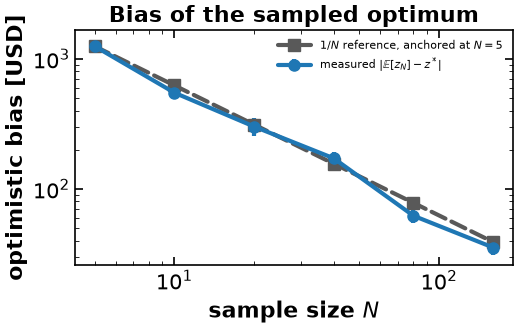

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.errorbar(
    sizes,
    [-b for b in bias_mean],
    yerr=bias_se,
    marker="o",
    linestyle="-",
    color="tab:blue",
    label=r"measured $|\mathbb{E}[z_N] - z^*|$",
)
reference = abs(bias_mean[0]) * sizes[0] / np.array(sizes, dtype=float)
ax.plot(
    sizes,
    reference,
    marker="s",
    linestyle="--",
    color="0.35",
    label=r"$1/N$ reference, anchored at $N=5$",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("sample size $N$")
ax.set_ylabel("optimistic bias [USD]")
ax.set_title("Bias of the sampled optimum")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

### An optimality-gap certificate for one candidate plan

Now the estimator the lecture presents. Take a candidate $\hat{\mathbf{x}}$ from a
deliberately small training sample, then assess it on $T$ **fresh, independent**
batches. Within a batch, evaluate the candidate and re-optimize on the *same*
realizations — common random numbers — so that

$$G_j = \hat q^{\,j}_N(\hat{\mathbf{x}}) - \min_{\mathbf{x}\in X}\hat q^{\,j}_N(\mathbf{x}) \ge 0$$

is a paired difference. The one-sided bound is
$\bar G + t_{T-1,1-\delta}\, s_G/\sqrt{T}$.

The training sample is never reused here. Reusing it would report the training
objective's own optimism as if it were a bound.


In [8]:
# Training: a deliberately small sample, so the candidate is visibly imperfect.
rng_gap = np.random.default_rng(31415)
xi_train = rng_gap.uniform(0.8, 1.2, 20)
z_train, x_hat = saa_optimum(xi_train)
q_hat = evaluate_candidate(x_hat, REF_NODES, REF_WEIGHTS)
true_gap = q_hat - Z_STAR

print(
    f"candidate from N = 20: wheat {x_hat[0]:.1f}, corn {x_hat[1]:.1f}, "
    f"beets {x_hat[2]:.1f} acres"
)
print(f"training objective z_20      = {z_train:12,.2f}  (optimistic, not a bound)")
print(f"true expected cost q(x_hat)  = {q_hat:12,.2f}")
print(f"TRUE optimality gap          = {true_gap:12,.2f}  <- known only because")
print("                                               the reference exists\n")


def gap_bound(x_candidate, T, N, delta, seed):
    """Multiple-replication optimality-gap bound for a fixed candidate.

    Returns (G, bound). Each batch is fresh and independent of the others;
    within a batch the candidate evaluation and the re-optimization share the
    realizations, which is the paired (common random numbers) estimator.
    """
    rng_local = np.random.default_rng(seed)
    G = np.empty(T)
    for j in range(T):
        xi = rng_local.uniform(0.8, 1.2, N)
        G[j] = evaluate_candidate(x_candidate, xi) - saa_optimum(xi)[0]
    t_crit = stats.t.ppf(1.0 - delta, T - 1)  # ONE-sided critical value
    bound = G.mean() + t_crit * G.std(ddof=1) / np.sqrt(T)
    return G, bound


print("  T     N      G_bar       s_G     one-sided 95% bound    covers true gap?")
for T, N, seed in ((30, 50, 9001), (30, 200, 9002), (100, 200, 9003)):
    G, bound = gap_bound(x_hat, T=T, N=N, delta=0.05, seed=seed)
    assert (G >= -1e-6).all(), "paired gaps are nonnegative by construction"
    print(
        f"{T:4d} {N:5d}  {G.mean():9,.2f}  {G.std(ddof=1):8,.2f}  "
        f"{bound:18,.2f}    {'yes' if bound >= true_gap else 'NO'}"
    )

candidate from N = 20: wheat 133.5, corn 89.1, beets 277.4 acres
training objective z_20      =  -107,210.81  (optimistic, not a bound)
true expected cost q(x_hat)  =  -111,193.97
TRUE optimality gap          =        43.47  <- known only because
                                               the reference exists

  T     N      G_bar       s_G     one-sided 95% bound    covers true gap?


  30    50     138.27     96.77              168.29    yes


  30   200      76.50     51.40               92.45    yes


 100   200      71.88     48.45               79.92    yes


Read the table with the lecture's cautions in hand.

* **The bound is not the gap.** $\mathbb{E}[G_j] = q(\hat{\mathbf{x}}) - \mu_N$,
  and $\mu_N \le z^{*}$, so $\bar G$ estimates something *larger* than the true
  gap. The bound is conservative on purpose, and the `G_bar` column sitting well
  above the true gap is that conservatism, not an error. Raising $N$ shrinks it,
  because $\mu_N$ climbs toward $z^{*}$; raising $T$ only shrinks the $t$-term.
* **The $t$-interval is approximate.** It leans on a central limit theorem for
  the replicate mean. Lecture 10 records $T \ge 30$ as a reported rule of thumb,
  not a guarantee for every distribution, and that is the status of the $T=30$
  rows here.
* **These are not joint statements.** The rows are separate nominal 95%
  one-sided bounds computed from separate seeds. Three of them do not certify
  anything at a joint 95% level, and neither does combining a candidate-value
  interval with a lower-bound interval.
* **`covers true gap?` is a check available only here.** It is not part of the
  procedure and cannot be run in a real study. It is printed because a
  demonstration of a statistical bound should be checked against the answer when
  the answer happens to be known — and because one run agreeing proves nothing
  about coverage, which is a statement about many runs.

Everything above is seeded. Changing `default_rng(...)` in any cell is the
intended way to see how much of what you just read was the draw.


## References

* Birge and Louveaux (2011), *Introduction to Stochastic Programming*, 2nd ed., Springer. The farmer's problem and its data are §1.1a–b, pp. 4–8 (data in Table 1, p. 5); the three-scenario solution used as a check is Table 5, p. 8; the continuous uniform-yield version is §1.1d, p. 11.
* Mak, Morton and Wood (1999), *Monte Carlo bounding techniques for determining solution quality in stochastic programs*, DOI: [10.1016/S0167-6377(98)00054-6](https://doi.org/10.1016/S0167-6377(98)00054-6).
* Bayraksan and Morton (2006), *Assessing solution quality in stochastic programs*, DOI: [10.1007/s10107-006-0720-x](https://doi.org/10.1007/s10107-006-0720-x).
* [NumPy Gauss–Legendre documentation](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.legendre.leggauss.html): exactness through degree $2n-1$.
* [Tasmanian project documentation](https://ornl.github.io/TASMANIAN/rolling/): optional sparse-grid software.

The two comparison figures are original course illustrations. The sparse-grid picture displays nodes, not quadrature weights or an error bound.
